In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


In [2]:
%matplotlib widget
plt.close('all')

In [3]:
annealing_data = "data/annealing"
data = np.loadtxt(os.path.join(annealing_data, "data_20nm_annealing.txt"))


In [4]:
print(data)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.966113e+03 9.900000e+37]
 [8.966498e+03 9.900000e+37]
 [8.966888e+03 9.900000e+37]]


In [5]:
#rimuovo gli zeri e i dati di overload
mask = (data[:, 1] != 0) & (data[:, 1] < 1e3)
data = data[mask]

In [6]:
print(data)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.838188e+03 8.075347e+02]
 [8.838258e+03 8.089226e+02]
 [8.838327e+03 8.129338e+02]]


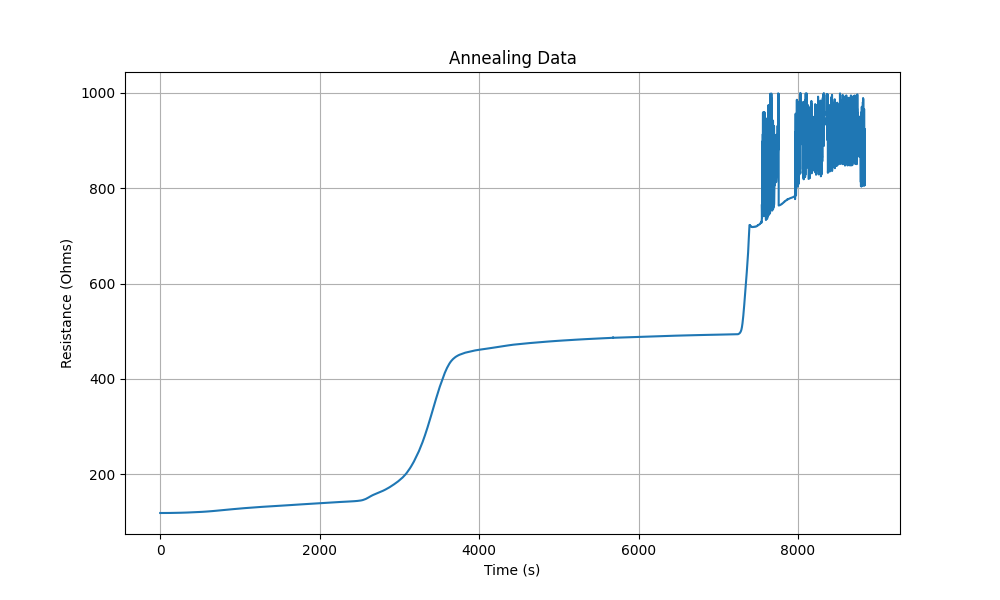

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], data[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.grid()
plt.show()

In [8]:
#tengo solo i dati della curva percolativa
mask_final = (data[:, 0] < 7.24e3) & (data[:, 1] > 0)
data = data[mask_final]

In [9]:
print(data)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [7.239795e+03 4.936693e+02]
 [7.239862e+03 4.936699e+02]
 [7.239931e+03 4.936702e+02]]


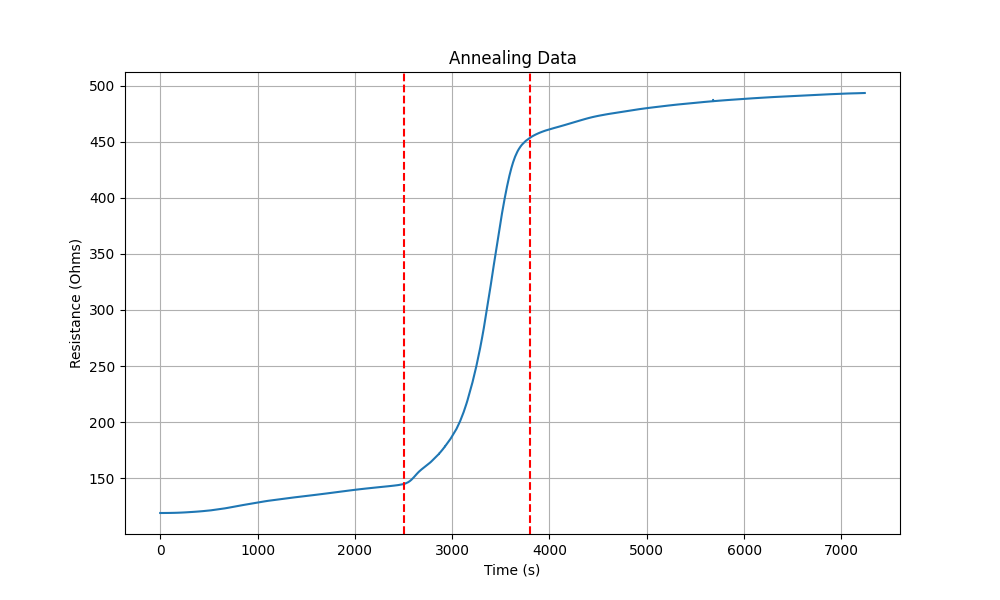

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], data[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.axvline(2.5e3, color="red", linestyle="--")
plt.axvline(3.8e3, color="red", linestyle="--")
plt.grid()
plt.show()

Sembra esserci un aumento lineare della resistenza nel tempo prima dei 2500 s.
Nello stesso intervallo di tempo anche la T sembra avere un andamento lineare.
Verifichiamo l'ipotesi che in questo intervallo di tempo si ha una relazione di proporzionalità tra la R e la T.

In [11]:
#selezione dei dati di interesse
mask1 = data[:, 0] < 2.5e3
data1 = data[mask1]

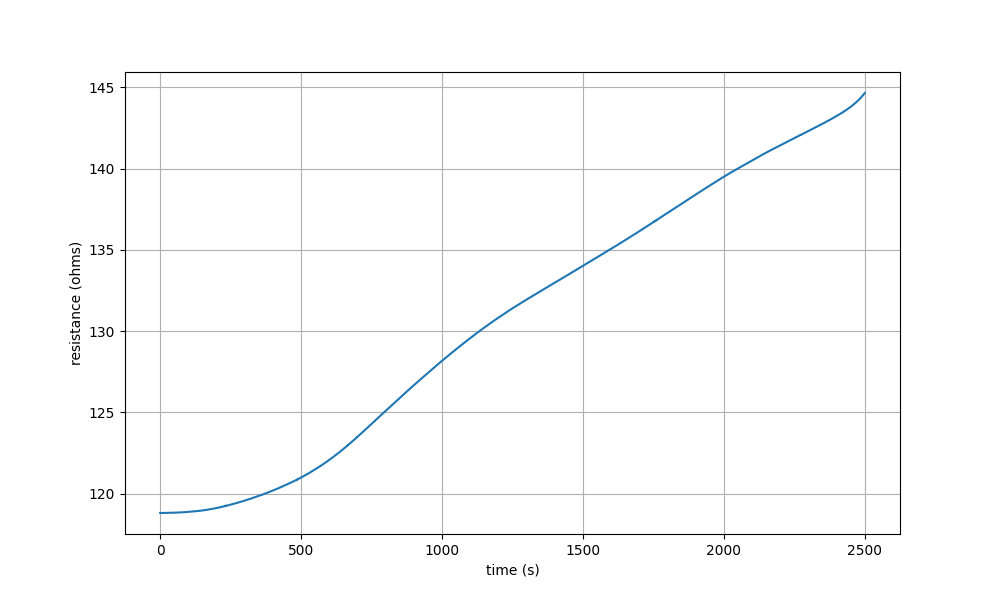

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(data1[:, 0], data1[:, 1])
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()

In [13]:
m,q = np.polyfit(data1[:, 0], data1[:, 1], 1)
print(m,q)

0.011370919415663214 116.55305797792427


In [14]:
R_fit = m*data1[:,0] + q
plt.plot(data1[:,0], R_fit)
plt.axvline(1690, color="red", linestyle="--")

In [15]:
data_time_temp_20nm = np.loadtxt(os.path.join(annealing_data, "time_temp_20nm.txt"))

temp_interp = np.array(np.interp(data1[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))

In [16]:
print(len(temp_interp))
print(len(data1[:,1]))

36482
36482


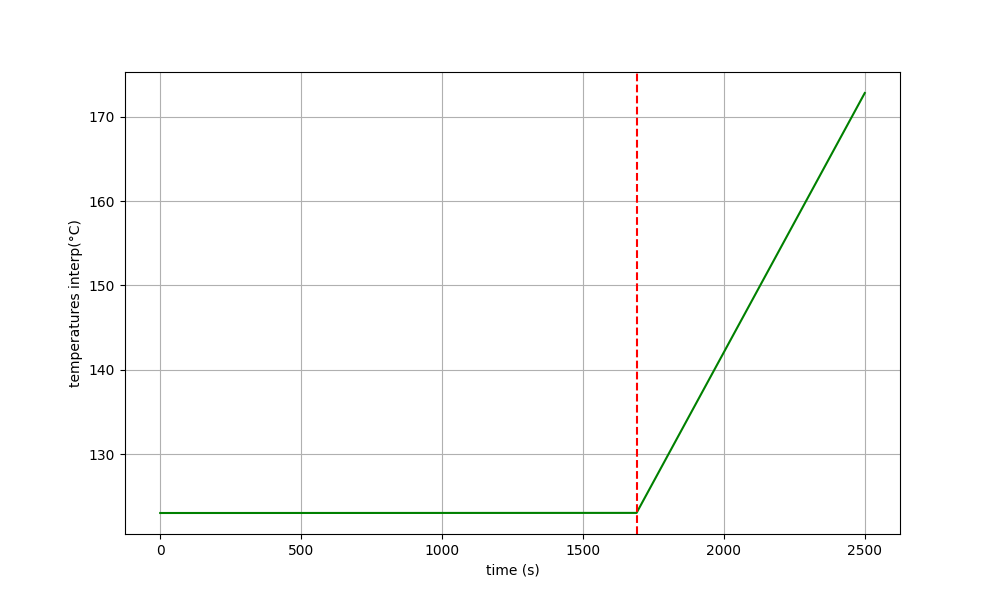

In [17]:
plt.figure(figsize=(10,6))
plt.plot(data1[:,0], temp_interp, color="green")
plt.axvline(1690, color="red", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("temperatures interp(°C)")
plt.grid()
plt.show()

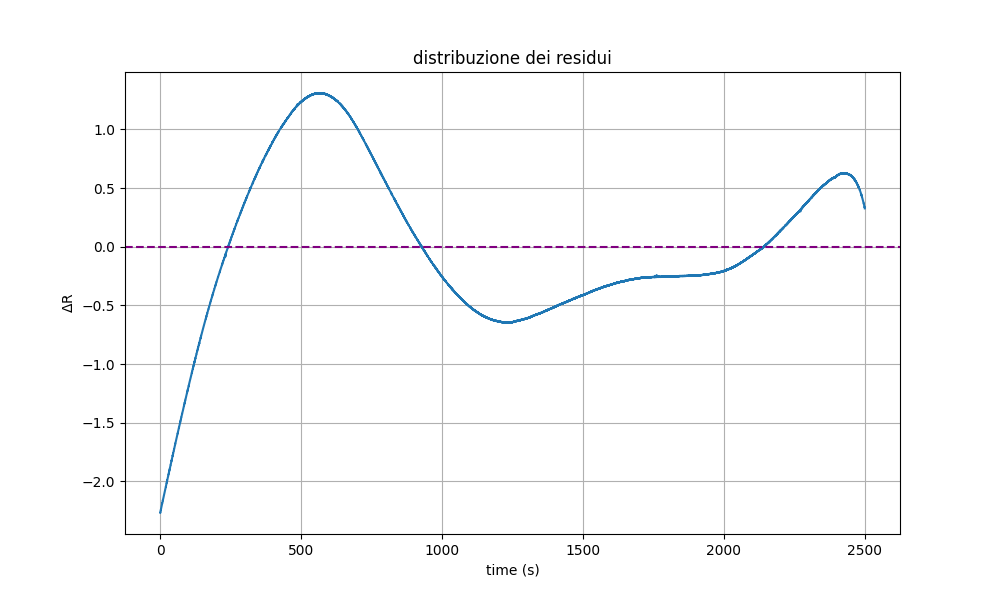

In [18]:
diff_R = R_fit - data1[:,1]

plt.figure(figsize=(10,6))
plt.plot(data1[:,0], diff_R)
plt.title("distribuzione dei residui")
plt.ylabel("$\Delta$R")
plt.xlabel("time (s)")
plt.axhline(0, color="purple", linestyle="--")
plt.grid()
plt.show()

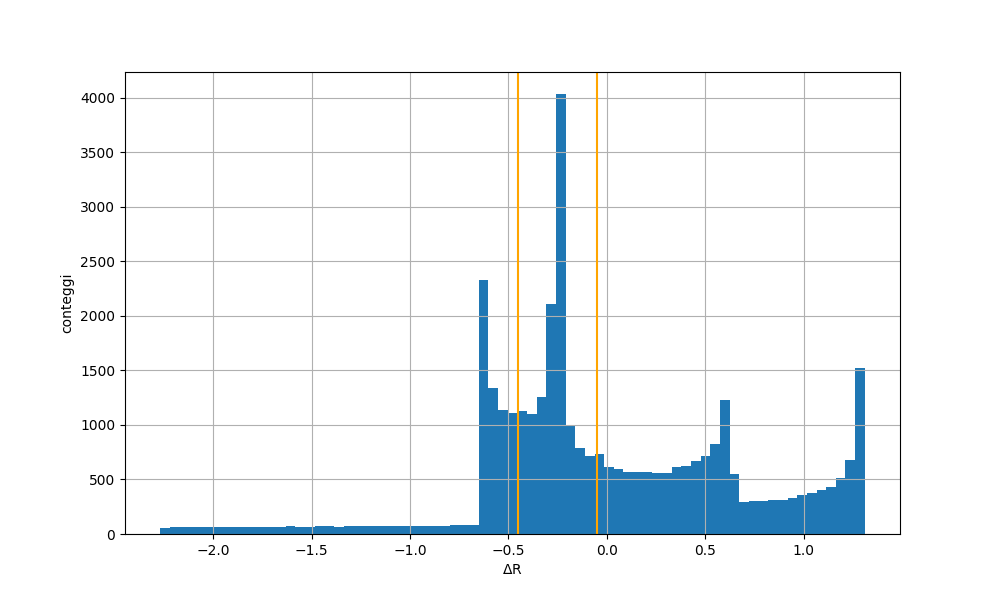

In [36]:
plt.figure(figsize=(10,6))
N = round(len(diff_R)/500) #nbins
plt.hist(diff_R, N)

mask2 = (diff_R < -0.05) & (diff_R > -0.45)
diff_R_masked = diff_R[mask2]

#plt.hist(diff_R_masked, round(len((diff_R_masked/100))), color="green")
plt.axvline(-0.45, color="orange")
plt.axvline(-0.05, color="orange")
plt.ylabel("conteggi")
plt.xlabel("$\Delta$R")
plt.grid()
plt.show()

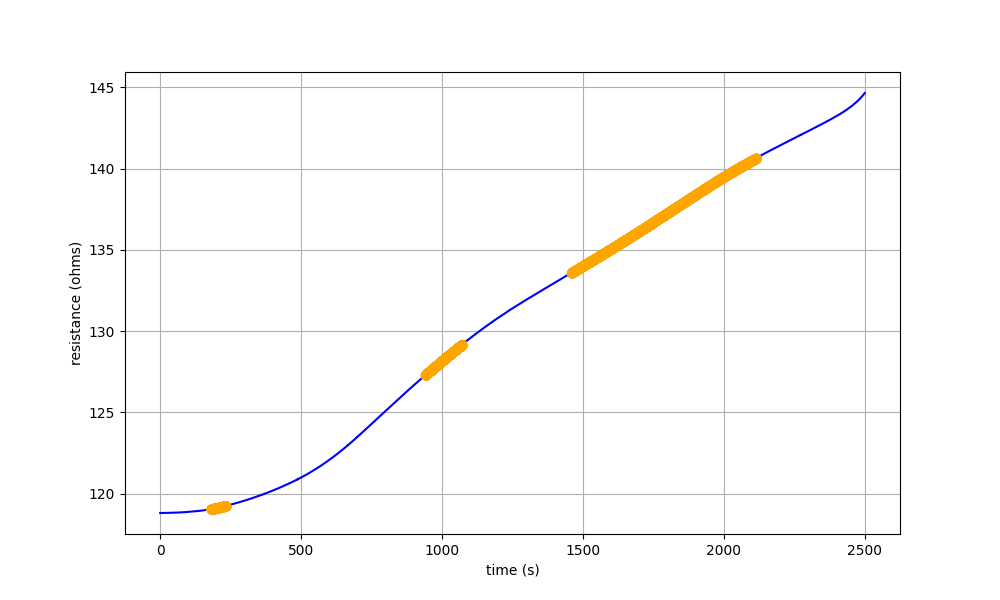

In [37]:
data_res_exp_masked = data1[:,1][mask2]
data_time_exp_masked = data1[:,0][mask2]

plt.figure(figsize=(10,6))
plt.plot(data1[:,0], data1[:,1], color="blue")
plt.plot(data_time_exp_masked, data_res_exp_masked, color="orange", linestyle="None", marker="o")
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()



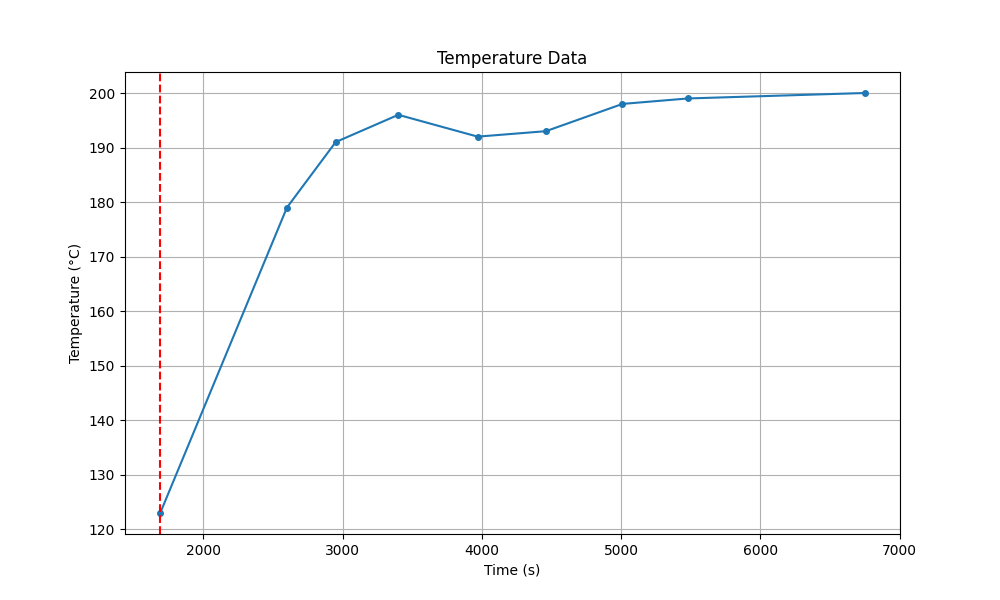

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(data_time_temp_20nm[:, 0], data_time_temp_20nm[:, 1], marker='o', markersize=4, linestyle='-')
plt.title("Temperature Data")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.axvline(1690, color="red", linestyle="--" )
plt.grid()
plt.show()

In [22]:
#print(data1.where(data1==1690)[0])


11821
11821


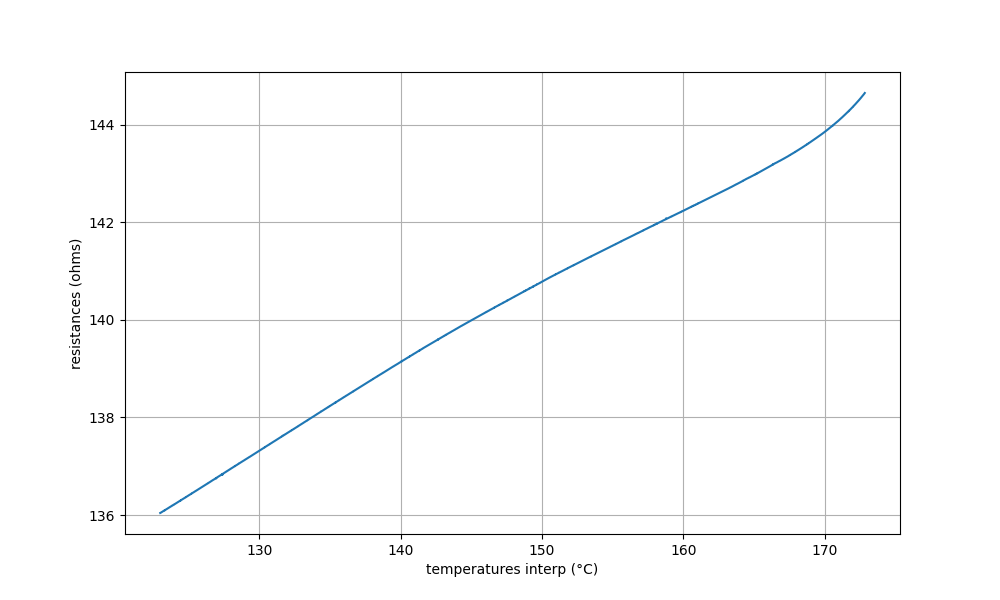

In [27]:
#plotto solo per tempi maggiori di 1690 s
mask3 = data1[:,0]>1690
data1_over1690 = data1[mask3]
print(len(data1_over1690))
temp_interp_over1690s = temp_interp[mask3]
print(len(temp_interp_over1690s))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_over1690s, data1_over1690[:,1])
plt.xlabel("temperatures interp (°C)")
plt.ylabel("resistances (ohms)")
plt.grid()
plt.show()


In [28]:
m1, q1 = np.polyfit(temp_interp_over1690s, data1_over1690[:,1], 1)
print(m1,q1)

y_fit = m1 * temp_interp_over1690s +q1
plt.plot(temp_interp_over1690s, y_fit, color="orange")

0.16357353331959892 116.12389111821055
